### 1. Загрузите выборку из файла gbm-data.csv 
с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма). 
В первой колонке файла с данными записано, была или нет реакция.
Все остальные колонки (d1-d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. 
Разбейте выборку на обучающую и тестовую, используя функцию `train_test_split` с
параметрами `test_size = 0.8` и `random_state = 241`.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('gbm-data.csv')

X, y = df.iloc[:, 1:], df['Activity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.8, random_state = 241) # мб train_size = 0.8 а не test_size?

### 2. Обучите GradientBoostingClassifier 
с параметрами `n_estimators=250, verbose=True,random_state=241` и для каждого значения 
`learning_rate` из списка `[1, 0.5, 0.3, 0.2, 0.1]` проделайте следующее:
```
• Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой итерации.
• Преобразуйте полученное предсказание поформуле 1/(1+e^-y_pred)
где y_pred — предсказанное значение.
• Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, 
а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.
```

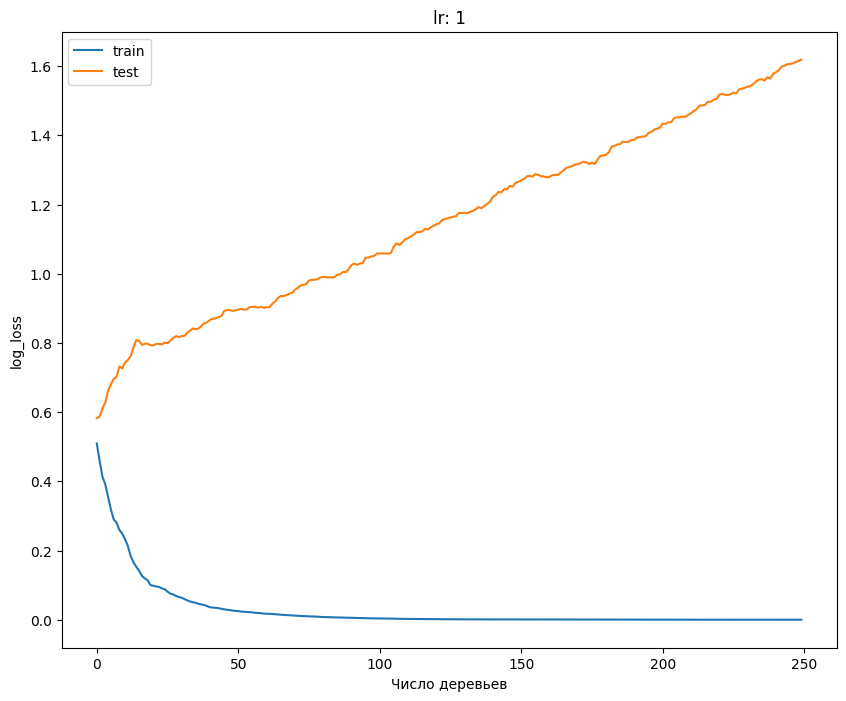

минимальное значение метрики на тесте: 0.58, номер итерации: 1


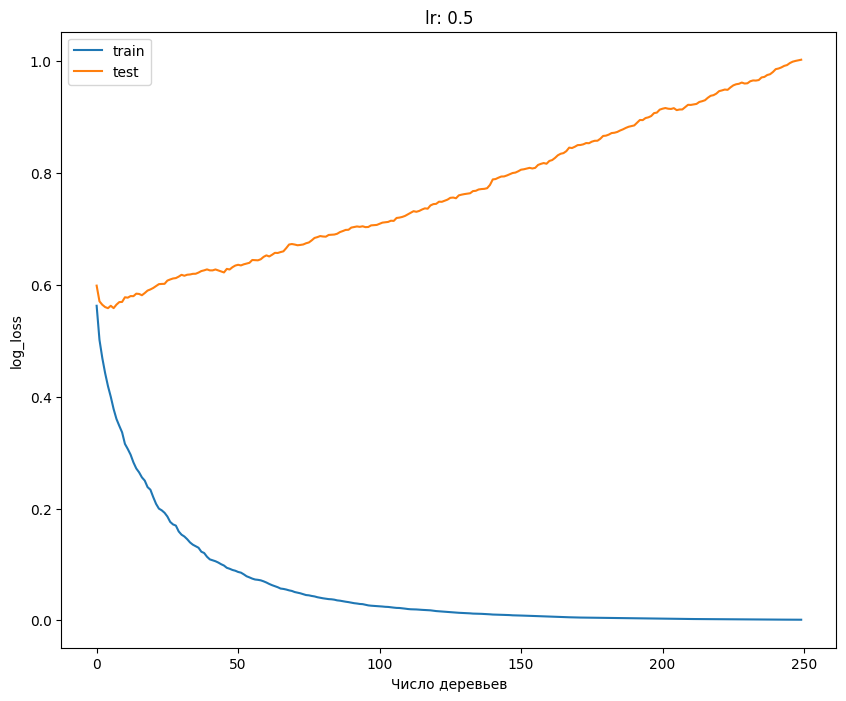

минимальное значение метрики на тесте: 0.56, номер итерации: 5


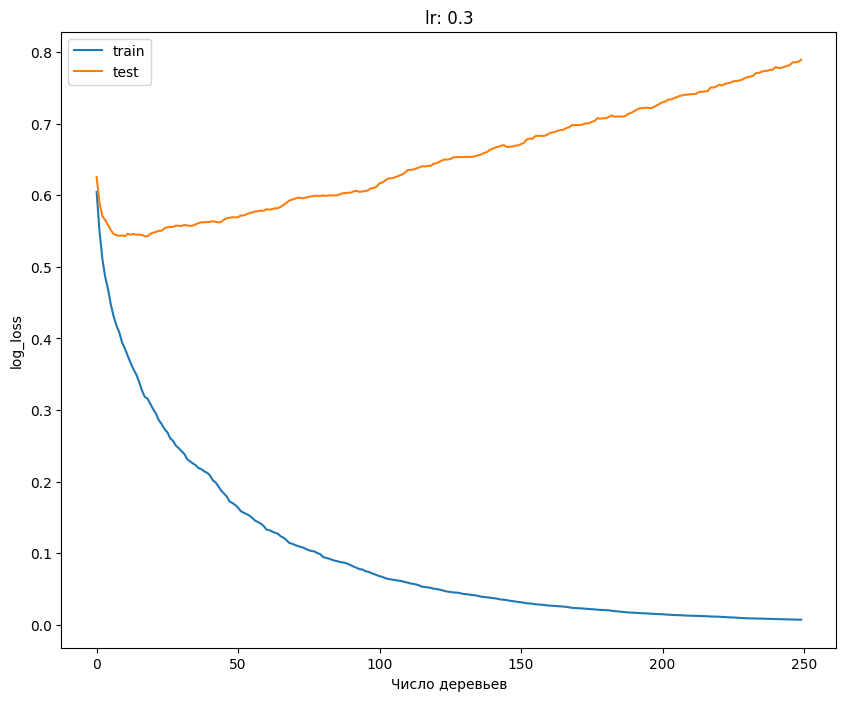

минимальное значение метрики на тесте: 0.54, номер итерации: 19


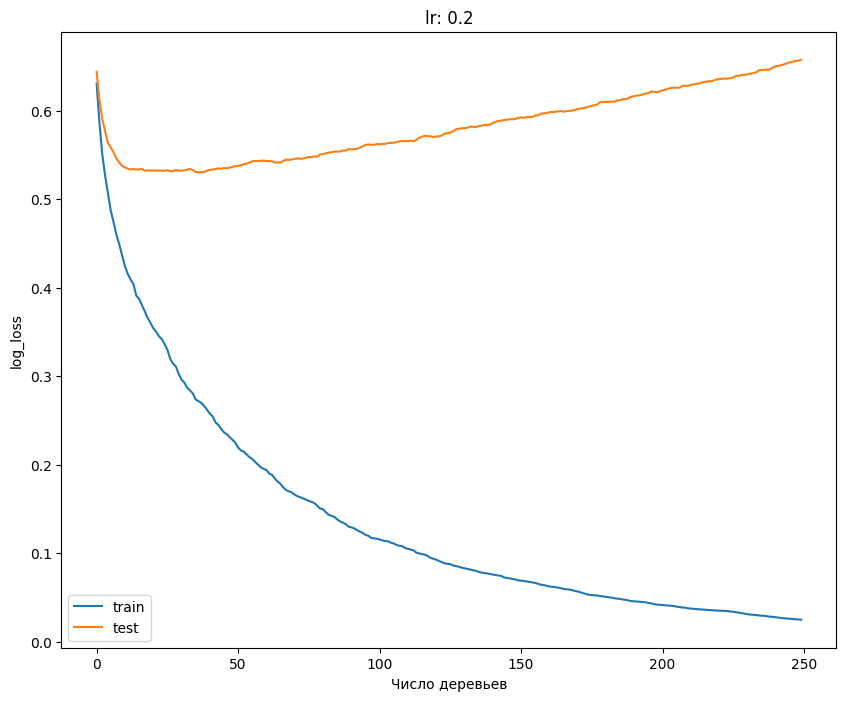

минимальное значение метрики на тесте: 0.53, номер итерации: 37


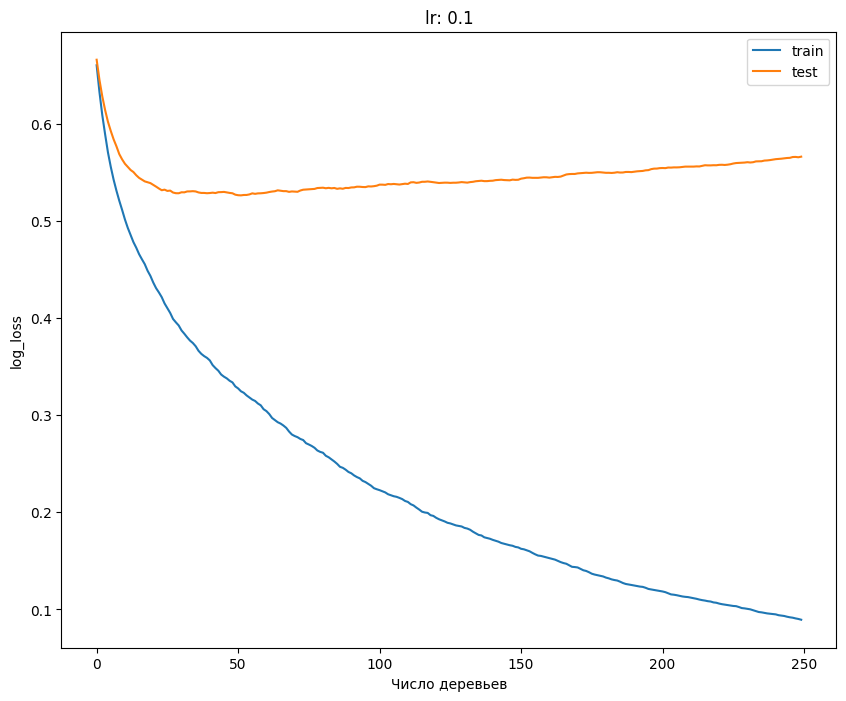

минимальное значение метрики на тесте: 0.53, номер итерации: 52


In [2]:
import  numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss 
import matplotlib.pyplot as plt
gbc = GradientBoostingClassifier(n_estimators = 250, verbose = True, random_state = 241)

learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
results = []
for lr in learning_rates:
    gbc = GradientBoostingClassifier(n_estimators = 250, verbose = False, random_state = 241, learning_rate = lr)
    gbc.fit(X_train,y_train)
    
    train_stages = gbc.staged_decision_function(X_train)
    test_stages = gbc.staged_decision_function(X_test)

    train_loss, test_loss = [], []
    for logit_train, logit_test in zip(train_stages, test_stages):
        
        proba_train = 1 / (1+ np.exp(-logit_train))
        proba_test = 1 / (1+ np.exp(-logit_test))

        train_loss.append(log_loss(y_train, proba_train))
        test_loss.append(log_loss(y_test, proba_test))
    plt.figure(figsize=(10,8))
    plt.plot(train_loss, label = 'train')
    plt.plot(test_loss, label = 'test')
    plt.xlabel('Число деревьев')
    plt.ylabel('log_loss')
    plt.title(f'lr: {lr}')
    plt.legend()
    plt.show()

    optimal_idx = np.argmin(test_loss)
    results.append([round(test_loss[optimal_idx],2),optimal_idx+1])
    print(f'минимальное значение метрики на тесте: {round(test_loss[optimal_idx],2)}, номер итерации: {optimal_idx+1}')

### 3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: 
переобучение (overfitting) или
недообучение (underfitting)? В ответе укажите одно из слов overfitting
либо underfitting.

In [3]:
print('overfitting')

overfitting


### 4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, 
на котором оно достигается, при `learning_rate =
0.2.`

In [4]:
print(f'минимальное значение log-loss на тестовой выборке: {results[-2][0]}, номер итерации: {results[-2][1]} при learning_rate = 0.2')

минимальное значение log-loss на тестовой выборке: 0.53, номер итерации: 37 при learning_rate = 0.2


### 5. На этих же данных обучите RandomForestClassifier 
с количеством деревьев, равным количеству итераций, на котором достигается
наилучшее качество у градиентного бустинга из предыдущего пункта, `random_state=241` и остальными параметрами по умолчанию.
Какое значение log-loss на тесте получается у этого случайного леса? 
(Не забывайте, что предсказания нужно получать с помощью
функции `predict_proba`.В данном случае брать сигмоиду от оценки
вероятности класса не нужно)

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss

rfc = RandomForestClassifier(random_state = 241, n_estimators = results[-2][1])
rfc.fit(X_train, y_train)
predict_proba = rfc.predict_proba(X_test)
print(f'значение log-loss: {round(log_loss(y_test, predict_proba),2)}')

значение log-loss: 0.54
